# Percentile Method for detection of Outliers

- set a threshold using percentiles to define the boundaries for outlier detection
- ex : >99%ile or <1%ile -> outliers
- the gap from the edge percentiles(0 and 100) must be equal (0., 99.5; 1,99; 2,98; etc)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('../datasets/placement_new.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
981,8.06,37.0,0
393,6.60,18.0,0
102,5.92,22.0,1
588,6.38,25.0,0
960,6.81,10.0,1


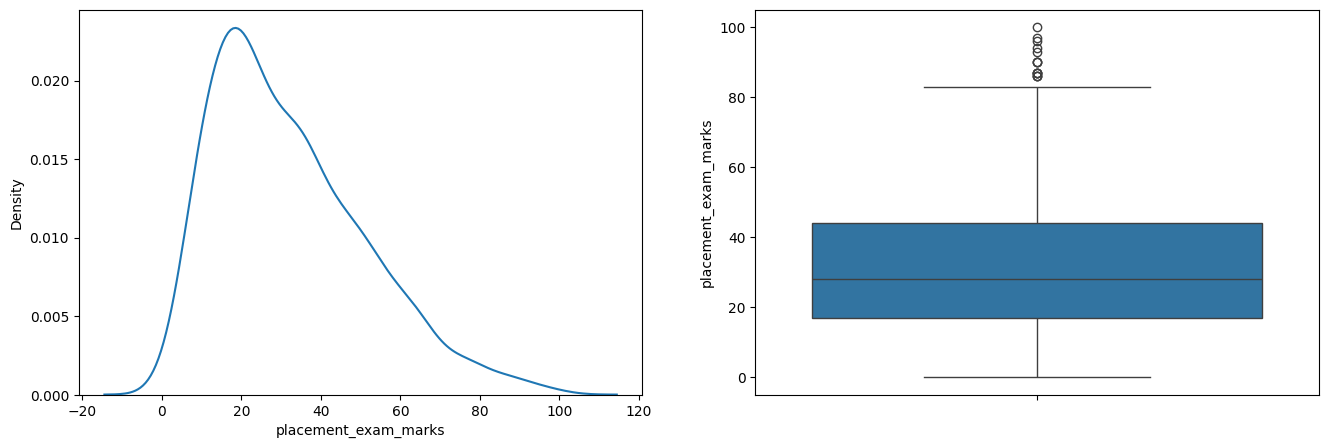

In [11]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(1,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.show()

Let's decide the threshold to be and  1 and 99%iles

In [12]:
# boundary values
upper_limit = df['placement_exam_marks'].quantile(0.99)
lower_limit = df['placement_exam_marks'].quantile(0.01)

In [13]:
# detecting the outiers
outliers = df[(df['placement_exam_marks']>upper_limit) | (df['placement_exam_marks'] < lower_limit)]
outliers.count()

cgpa                    14
placement_exam_marks    14
placed                  14
dtype: int64

In [ ]:
# Removing outliers / Trimming
new_df = df[(df['placement_exam_marks'] <= upper_limit) & (df['placement_exam_marks'] >= lower_limit)]
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: ylabel='placement_exam_marks'>

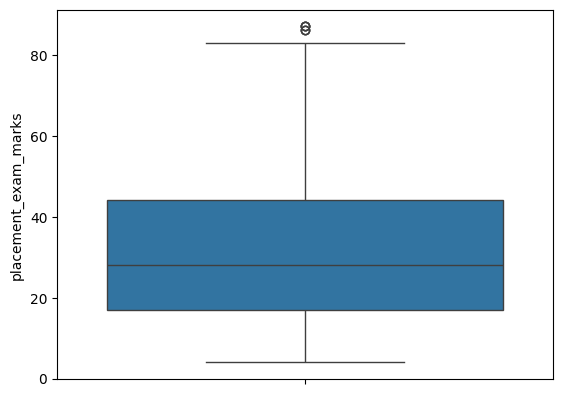

In [17]:
sns.boxplot(new_df['placement_exam_marks'])

We can still see a few outliers left. SO lets try updating the values of the boundary percentiles

In [21]:
# boundary values
upper_limit = df['placement_exam_marks'].quantile(0.9877)
lower_limit = df['placement_exam_marks'].quantile(0.0123)

In [22]:
# detecting the outiers
outliers = df[(df['placement_exam_marks']>upper_limit) | (df['placement_exam_marks'] < lower_limit)]
outliers.count()

cgpa                    18
placement_exam_marks    18
placed                  18
dtype: int64

In [23]:
# trimming
new_df = df[(df['placement_exam_marks'] <= upper_limit) & (df['placement_exam_marks'] >= lower_limit)]
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: ylabel='placement_exam_marks'>

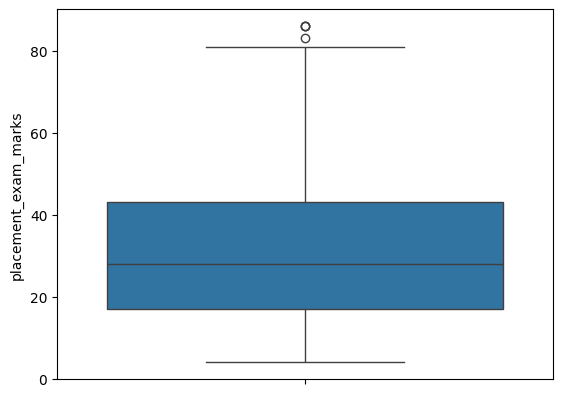

In [24]:
sns.boxplot(new_df['placement_exam_marks'])

We still have 2 T_T. But at least you get the gist of it.

### Note : When capping follows percentile method, then that whole technique is termed as Winsorization method